### 1. 用全连接神经网络判断数字

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pylab as plt
%matplotlib inline

In [2]:

input_size = 784
hidden_size = 100
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [3]:
# 加载MNIST数据 
train_dataset = torchvision.datasets.MNIST(root='../data/MNIST_data', #数据存在这里
                                           train=True, #标记为训练数据
                                           transform=transforms.ToTensor(),#转换成torch.tensor
                                           download=True)#不够就下载

test_dataset = torchvision.datasets.MNIST(root='../data/MNIST_data', 
                                          train=False, #标记成测试数据
                                          transform=transforms.ToTensor())



In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, #去这里读数据
                                           batch_size=batch_size, #按照每批几个去读
                                           shuffle=True) #通过洗牌随机化batch

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, #和上面一样，只是这里搞测试数据
                                          batch_size=batch_size, 
                                          shuffle=False)

torch.Size([100, 1, 28, 28])
torch.Size([100])


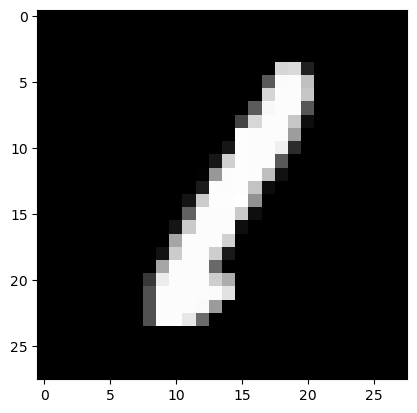

In [27]:
for i,(images,labels) in  enumerate(train_loader):
    plt.imshow(images[0,0,:,:],cmap='gray');#显示shuffle过后第一幅图，所以是随机的
    if i > 1:
        print(images.shape)#[100,1,28,28]100个图，每个图下面只有一个子图，每个子图是一个28*28的数组
        print(labels.shape)#[100] 100个label
        break
#print(labels)#每个图形对应的数字


In [28]:

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):#input_size图像尺寸，hidden_size隐藏层大小，每个隐藏层都一样大，num_classes最后分类数（10）
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) #输入到第一隐藏层
        self.relu = nn.ReLU() #激活函数
        self.fc2 = nn.Linear(hidden_size, num_classes)#第一隐藏层到第二隐藏层  
    
    def forward(self, x):
        out = self.fc1(x) #输入到第一
        out = self.relu(out)#第一到第二
        out = self.fc2(out)#第二到输出分类
        return out

In [29]:
model = NeuralNet(input_size, hidden_size, num_classes)#一个神经网络实例

In [31]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()#损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  #优化方法


In [32]:

total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):  
        images = images.reshape(-1, 28*28)      #-1表示数据长度，也就是最后一个元素的位置

        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()#梯度清零
        loss.backward()#后向演化计算梯度
        optimizer.step()#用梯度走一步
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))


Epoch [1/5], Step [100/600], Loss: 0.4958
Epoch [1/5], Step [200/600], Loss: 0.4251
Epoch [1/5], Step [300/600], Loss: 0.2797
Epoch [1/5], Step [400/600], Loss: 0.1858
Epoch [1/5], Step [500/600], Loss: 0.2213
Epoch [1/5], Step [600/600], Loss: 0.1540
Epoch [2/5], Step [100/600], Loss: 0.2217
Epoch [2/5], Step [200/600], Loss: 0.2030
Epoch [2/5], Step [300/600], Loss: 0.1683
Epoch [2/5], Step [400/600], Loss: 0.3234
Epoch [2/5], Step [500/600], Loss: 0.1617
Epoch [2/5], Step [600/600], Loss: 0.1535
Epoch [3/5], Step [100/600], Loss: 0.1187
Epoch [3/5], Step [200/600], Loss: 0.1728
Epoch [3/5], Step [300/600], Loss: 0.1447
Epoch [3/5], Step [400/600], Loss: 0.1412
Epoch [3/5], Step [500/600], Loss: 0.2125
Epoch [3/5], Step [600/600], Loss: 0.0679
Epoch [4/5], Step [100/600], Loss: 0.1220
Epoch [4/5], Step [200/600], Loss: 0.1577
Epoch [4/5], Step [300/600], Loss: 0.1780
Epoch [4/5], Step [400/600], Loss: 0.0943
Epoch [4/5], Step [500/600], Loss: 0.0543
Epoch [4/5], Step [600/600], Loss:

In [38]:
with torch.no_grad():#关掉梯度计算功能可能快一点
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) #outputs 每一行是一个概率数组，表示图像等于1的概率2的概率等等，取其中最大一个最为我们的预测，每列都这样做
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))

Accuracy of the network on the 10000 test images: 96.96 %


### 2.  用全连接神经网络判断服饰类型

In [39]:
# MNIST dataset 
train_dataset = torchvision.datasets.FashionMNIST(root='../data/fasion_mnist', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.FashionMNIST(root='../data/fasion_mnist', 
                                          train=False, 
                                          transform=transforms.ToTensor())



In [41]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

torch.Size([100, 1, 28, 28])
torch.Size([100])


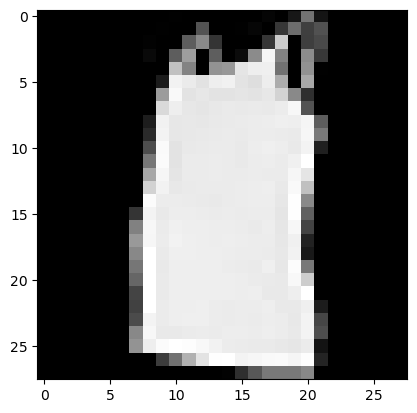

In [42]:
for i,(images,labels) in  enumerate(train_loader):
    plt.imshow(images[0,0,:,:],cmap='gray');
    if i > 1:
        print(images.shape)
        print(labels.shape)
        break

In [44]:
model_fashion = NeuralNet(input_size, hidden_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fashion.parameters(), lr=learning_rate)  


In [45]:

total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):  
        images = images.reshape(-1, 28*28)      

        outputs = model(images)
        loss = criterion(outputs, labels)
        

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/5], Step [100/600], Loss: 14.1173
Epoch [1/5], Step [200/600], Loss: 14.0454
Epoch [1/5], Step [300/600], Loss: 14.6683
Epoch [1/5], Step [400/600], Loss: 16.5907
Epoch [1/5], Step [500/600], Loss: 15.2571
Epoch [1/5], Step [600/600], Loss: 15.1545
Epoch [2/5], Step [100/600], Loss: 15.6623
Epoch [2/5], Step [200/600], Loss: 16.7427
Epoch [2/5], Step [300/600], Loss: 16.3872
Epoch [2/5], Step [400/600], Loss: 17.3383
Epoch [2/5], Step [500/600], Loss: 13.6713
Epoch [2/5], Step [600/600], Loss: 15.1026
Epoch [3/5], Step [100/600], Loss: 15.7753
Epoch [3/5], Step [200/600], Loss: 15.8590
Epoch [3/5], Step [300/600], Loss: 17.6743
Epoch [3/5], Step [400/600], Loss: 14.5560
Epoch [3/5], Step [500/600], Loss: 15.0533
Epoch [3/5], Step [600/600], Loss: 16.1902
Epoch [4/5], Step [100/600], Loss: 16.3018
Epoch [4/5], Step [200/600], Loss: 16.7379
Epoch [4/5], Step [300/600], Loss: 17.5391
Epoch [4/5], Step [400/600], Loss: 15.4508
Epoch [4/5], Step [500/600], Loss: 15.0103
Epoch [4/5]

In [46]:

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))


Accuracy of the network on the 10000 test images: 10.04 %


### 3. 用卷积神经网络判断服饰

In [19]:

num_epochs = 5
num_classes = 10
batch_size = 100
learning_rate = 0.001

In [20]:

class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.cnn_layer = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(14*14*32, num_classes)
        
    def forward(self, x):
        out = self.cnn_layer(x)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out


In [21]:
model_fashion_cnn = ConvNet(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fashion_cnn.parameters(), lr=learning_rate)

In [22]:
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        
        outputs = model_fashion_cnn(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))


Epoch [1/5], Step [100/600], Loss: 0.4598
Epoch [1/5], Step [200/600], Loss: 0.5903
Epoch [1/5], Step [300/600], Loss: 0.3828
Epoch [1/5], Step [400/600], Loss: 0.4964
Epoch [1/5], Step [500/600], Loss: 0.3470
Epoch [1/5], Step [600/600], Loss: 0.3416
Epoch [2/5], Step [100/600], Loss: 0.3006
Epoch [2/5], Step [200/600], Loss: 0.3538
Epoch [2/5], Step [300/600], Loss: 0.5296
Epoch [2/5], Step [400/600], Loss: 0.2037
Epoch [2/5], Step [500/600], Loss: 0.1881
Epoch [2/5], Step [600/600], Loss: 0.2037
Epoch [3/5], Step [100/600], Loss: 0.3125
Epoch [3/5], Step [200/600], Loss: 0.3285
Epoch [3/5], Step [300/600], Loss: 0.2498
Epoch [3/5], Step [400/600], Loss: 0.2975
Epoch [3/5], Step [500/600], Loss: 0.3747
Epoch [3/5], Step [600/600], Loss: 0.3266
Epoch [4/5], Step [100/600], Loss: 0.3912
Epoch [4/5], Step [200/600], Loss: 0.3139
Epoch [4/5], Step [300/600], Loss: 0.2289
Epoch [4/5], Step [400/600], Loss: 0.2697
Epoch [4/5], Step [500/600], Loss: 0.2292
Epoch [4/5], Step [600/600], Loss:

In [23]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model_fashion_cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Test Accuracy of the model on the 10000 test images: {} %'.format(100 * correct / total))


Test Accuracy of the model on the 10000 test images: 90.06 %
